# Homework 2

## Question 1

Plot the Bitcoin price series and its log returns, then comment on independence and stationarity based on the visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('bitcoin_data(1).csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df['Log Return'] = np.log(df['Close'] / df['Close'].shift(1))
returns_df = df.dropna(subset=['Log Return']).copy()

print(f'Observations: {len(df)}')
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Observations: 2556
Date range: 2018-01-01 to 2024-12-30


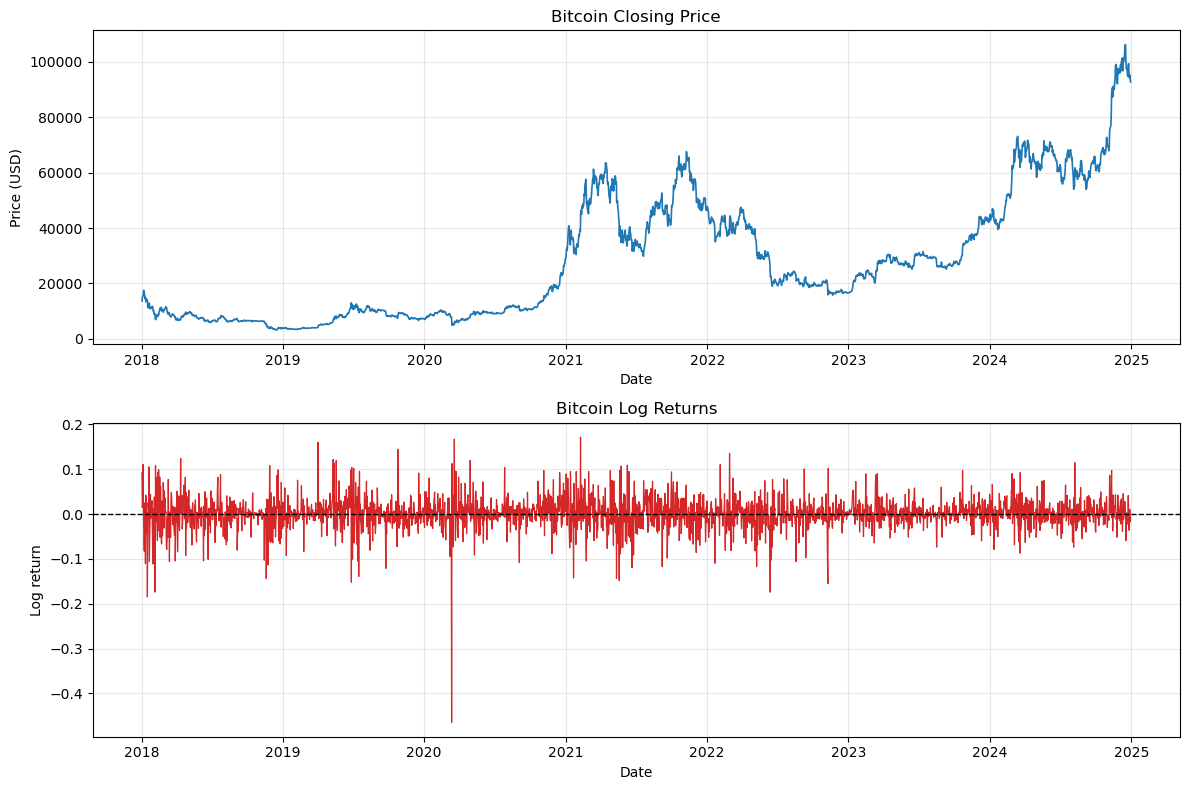

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(df['Date'], df['Close'], color='tab:blue', linewidth=1.2)
axes[0].set_title('Bitcoin Closing Price')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].grid(alpha=0.3)

axes[1].plot(returns_df['Date'], returns_df['Log Return'], color='tab:red', linewidth=0.9)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Bitcoin Log Returns')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Log return')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comments on Independence and Stationarity

From the price plot, the Bitcoin series is clearly **not stationary**: it shows long swings, changing levels, and persistent trends over time, so the mean is not stable. The strong visual persistence also suggests the price levels are **not independent**, since nearby observations move very closely together.

From the log-return plot, the series fluctuates around zero without an obvious long-run trend, which is more consistent with a **roughly stationary mean**. However, the volatility changes over time, with calm periods and volatility bursts, so the variance is not constant. This means the log returns look **more stationary than prices**, but not perfectly stationary. The returns also do not look fully independent because the volatility appears clustered: large moves are often followed by other large moves.

## Question 2

Compute and plot the ACF at various lags for the Bitcoin log returns, absolute returns, and squared returns. Then comment on short- and long-range dependence and on volatility clustering.

In [3]:
max_lag = 40

df['Absolute Return'] = df['Log Return'].abs()
df['Squared Return'] = df['Log Return'] ** 2

acf_df = pd.DataFrame({
    'Lag': range(1, max_lag + 1),
    'Log Return ACF': [returns_df['Log Return'].autocorr(lag=lag) for lag in range(1, max_lag + 1)],
    'Absolute Return ACF': [df['Absolute Return'].dropna().autocorr(lag=lag) for lag in range(1, max_lag + 1)],
    'Squared Return ACF': [df['Squared Return'].dropna().autocorr(lag=lag) for lag in range(1, max_lag + 1)]
})

acf_df.head()

,Lag,Log Return ACF,Absolute Return ACF,Squared Return ACF
0,1,-0.045227,0.150584,0.068601
1,2,0.047891,0.109567,0.030695
2,3,0.006808,0.104881,0.023269
3,4,0.028383,0.169253,0.073050
4,5,0.016939,0.123180,0.035543


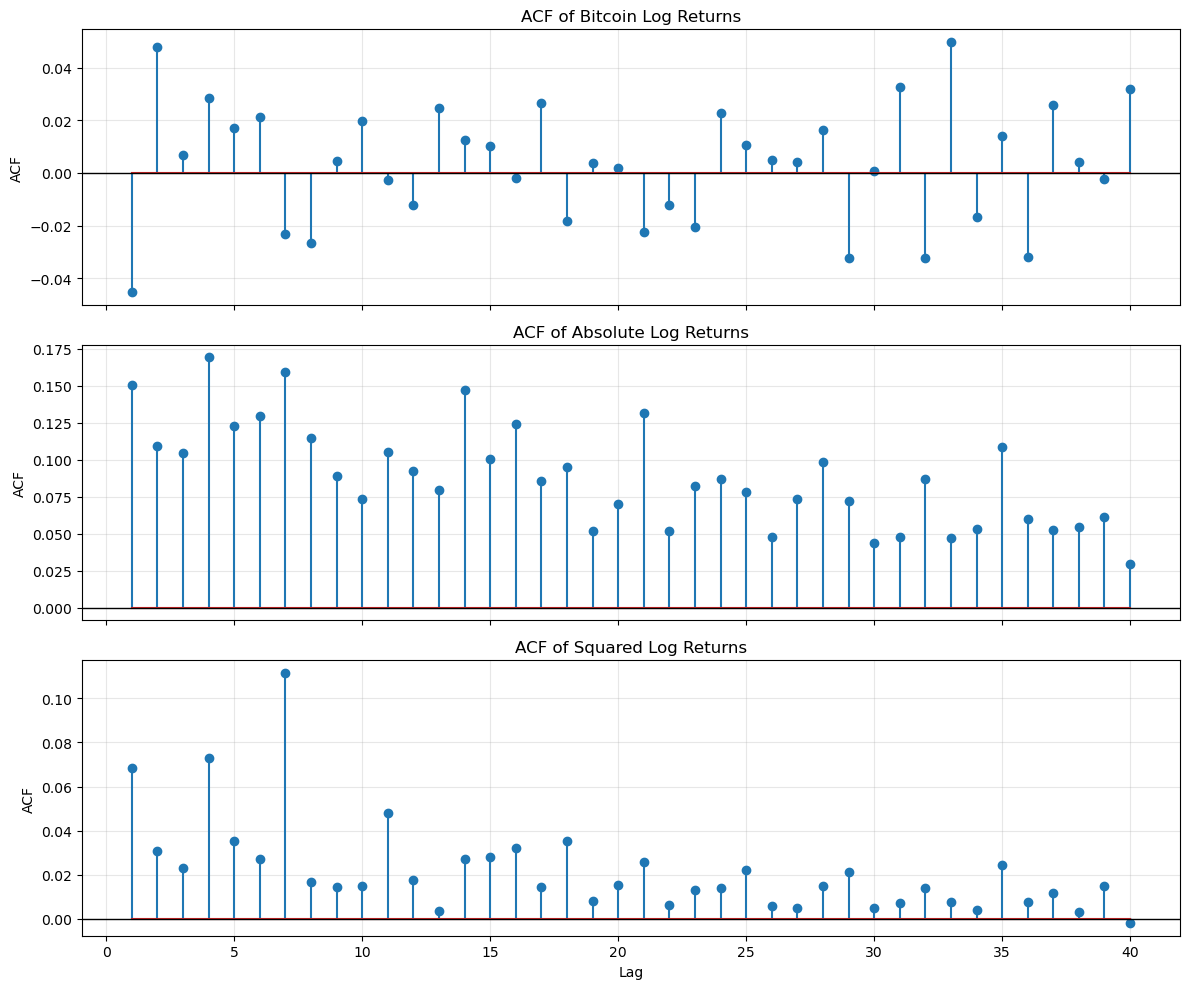

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].stem(acf_df['Lag'], acf_df['Log Return ACF'])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('ACF of Bitcoin Log Returns')
axes[0].set_ylabel('ACF')
axes[0].grid(alpha=0.3)

axes[1].stem(acf_df['Lag'], acf_df['Absolute Return ACF'])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('ACF of Absolute Log Returns')
axes[1].set_ylabel('ACF')
axes[1].grid(alpha=0.3)

axes[2].stem(acf_df['Lag'], acf_df['Squared Return ACF'])
axes[2].axhline(0, color='black', linewidth=1)
axes[2].set_title('ACF of Squared Log Returns')
axes[2].set_xlabel('Lag')
axes[2].set_ylabel('ACF')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Comments on ACF Results

The ACF of the **log returns** is usually small and close to zero at most lags, which suggests little linear predictability in the return series itself. This is consistent with **weak short-range dependence** and little evidence of strong long-range dependence in raw returns.

In contrast, the ACFs of the **absolute returns** and **squared returns** tend to remain positive across many lags and decay more slowly. That pattern indicates dependence in return magnitudes rather than in signed returns. This is a standard sign of **volatility clustering**: large shocks are likely to be followed by other large shocks, and quiet periods tend to be followed by quiet periods.

Therefore, the Bitcoin log returns may look close to serially uncorrelated in levels, but their volatility shows more persistent dependence over time.

## Question 3

Apply the Augmented Dickey-Fuller (ADF) test to both the Bitcoin price series and the Bitcoin log return series. State the null and alternative hypotheses and use the test results to determine whether each series is stationary or non-stationary.

### ADF Test Hypotheses

For the Augmented Dickey-Fuller (ADF) test:

- **Null hypothesis ($H_0$):** The series has a unit root, so it is **non-stationary**.
- **Alternative hypothesis ($H_1$):** The series does not have a unit root, so it is **stationary**.

The decision rule is: if the p-value is smaller than the chosen significance level (for example, 5%), reject the null hypothesis and conclude that the series is stationary.

In [5]:
from statsmodels.tsa.stattools import adfuller

price_adf = adfuller(df['Close'].dropna())
return_adf = adfuller(returns_df['Log Return'].dropna())

adf_results = pd.DataFrame({
    'Series': ['Bitcoin Price', 'Bitcoin Log Return'],
    'ADF Statistic': [price_adf[0], return_adf[0]],
    'p-value': [price_adf[1], return_adf[1]],
    'Used Lags': [price_adf[2], return_adf[2]],
    'Observations': [price_adf[3], return_adf[3]],
    'Conclusion at 5%': [
        'Stationary' if price_adf[1] < 0.05 else 'Non-stationary',
        'Stationary' if return_adf[1] < 0.05 else 'Non-stationary'
    ]
})

adf_results

,Series,ADF Statistic,p-value,Used Lags,Observations,Conclusion at 5%
0,Bitcoin Price,-0.337854,0.919969,27,2528,Non-stationary
1,Bitcoin Log Return,-34.905777,0.000000,1,2553,Stationary


In [6]:
critical_values = pd.DataFrame({
    'Significance Level': ['1%', '5%', '10%'],
    'Price Critical Value': [price_adf[4]['1%'], price_adf[4]['5%'], price_adf[4]['10%']],
    'Log Return Critical Value': [return_adf[4]['1%'], return_adf[4]['5%'], return_adf[4]['10%']]
})

critical_values

,Significance Level,Price Critical Value,Log Return Critical Value
0,1%,-3.432939,-3.432914
1,5%,-2.862684,-2.862673
2,10%,-2.567379,-2.567373


### Comments on ADF Results

At the 5% significance level, the ADF test for the **Bitcoin price series** gives an ADF statistic of **-0.337854** and a p-value of **0.919969**. Since the p-value is much larger than 0.05, we **fail to reject** the null hypothesis of a unit root. The test statistic is also higher than all reported critical values (1%: **-3.432939**, 5%: **-2.862684**, 10%: **-2.567379**), which leads to the same conclusion. Therefore, the **Bitcoin price series is non-stationary**.

For the **Bitcoin log return series**, the ADF statistic is **-34.905777** and the p-value is **0.000000**. Since the p-value is far below 0.05, we **reject** the null hypothesis of a unit root. In addition, the test statistic is far smaller than all reported critical values (1%: **-3.432914**, 5%: **-2.862673**, 10%: **-2.567373**). Therefore, the **Bitcoin log return series is stationary**.

Overall, the ADF test results confirm the earlier visual evidence: the **price level is non-stationary**, while the **log return series is stationary**. This is consistent with the common finding in financial time series that asset prices often contain a unit root, whereas returns are much closer to stationarity.